In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "macrophage_analysis").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Suppress noisy TensorFlow C++ startup logs in the notebook.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))


Num GPUs Available:  1


In [2]:
import macrophage_analysis as ma

comparison_donors = ["D45", "D47"]
comparison_condition = "B68KCP2"
comparison_marker_prefix = ma.DEFAULT_COMPARISON_MARKER_PREFIX
comparison_channel = ma.DEFAULT_COMPARISON_CHANNEL

batch_donors = ["D45", "D47"]
batch_conditions = list(ma.DEFAULT_CONDITIONS)
batch_plot_log_scale = False
batch_plot_upper_percentile = 99


Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


100%|██████████| 4/4 [00:00<00:00, 15.00it/s]


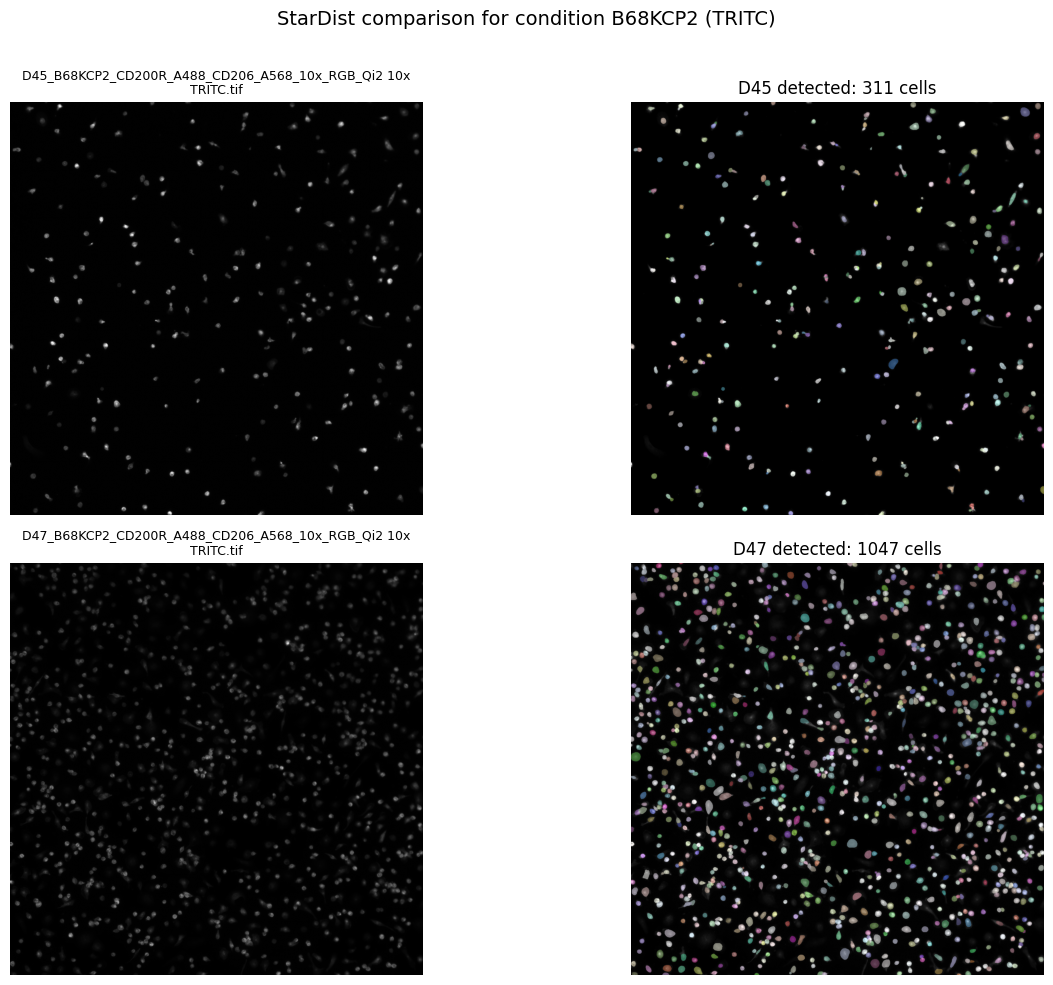

In [3]:
comparison_results = ma.extract_condition_comparison(
    donors=comparison_donors,
    condition=comparison_condition,
    marker_prefix=comparison_marker_prefix,
    channel=comparison_channel,
)

ma.plot_condition_comparison(comparison_results)


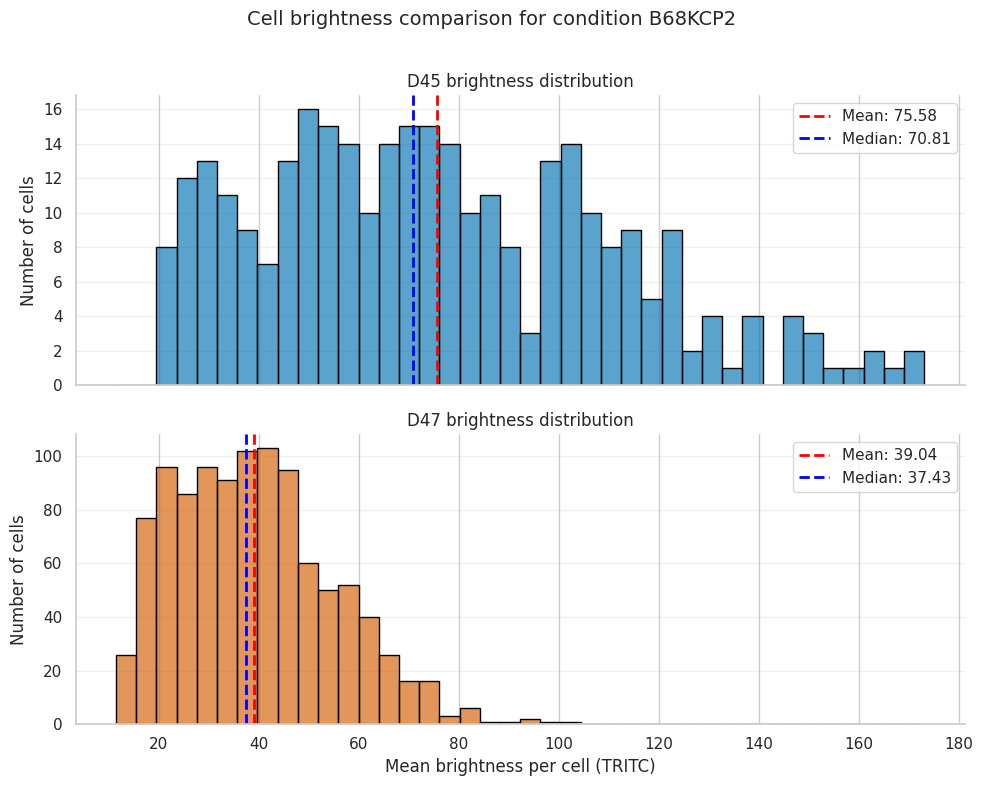

D45 | cells analyzed: 311 | mean: 75.58 | median: 70.81
D47 | cells analyzed: 1047 | mean: 39.04 | median: 37.43


In [4]:
ma.plot_condition_histograms(comparison_results)


In [5]:
batch_results = ma.extract_single_cell_fluorescence(
    donors=batch_donors,
    conditions=batch_conditions,
)


Analyzing CD40...


100%|██████████| 4/4 [00:00<00:00, 15.30it/s]


Analyzing CD86...


100%|██████████| 4/4 [00:00<00:00, 15.05it/s]


Analyzing iNOS...


...

Analyzing CD200R...


100%|██████████| 4/4 [00:00<00:00, 15.23it/s]


Analyzing CD206...


100%|██████████| 4/4 [00:00<00:00, 14.81it/s]


Finished analyzing 70 donor / treatment / antibody combinations.


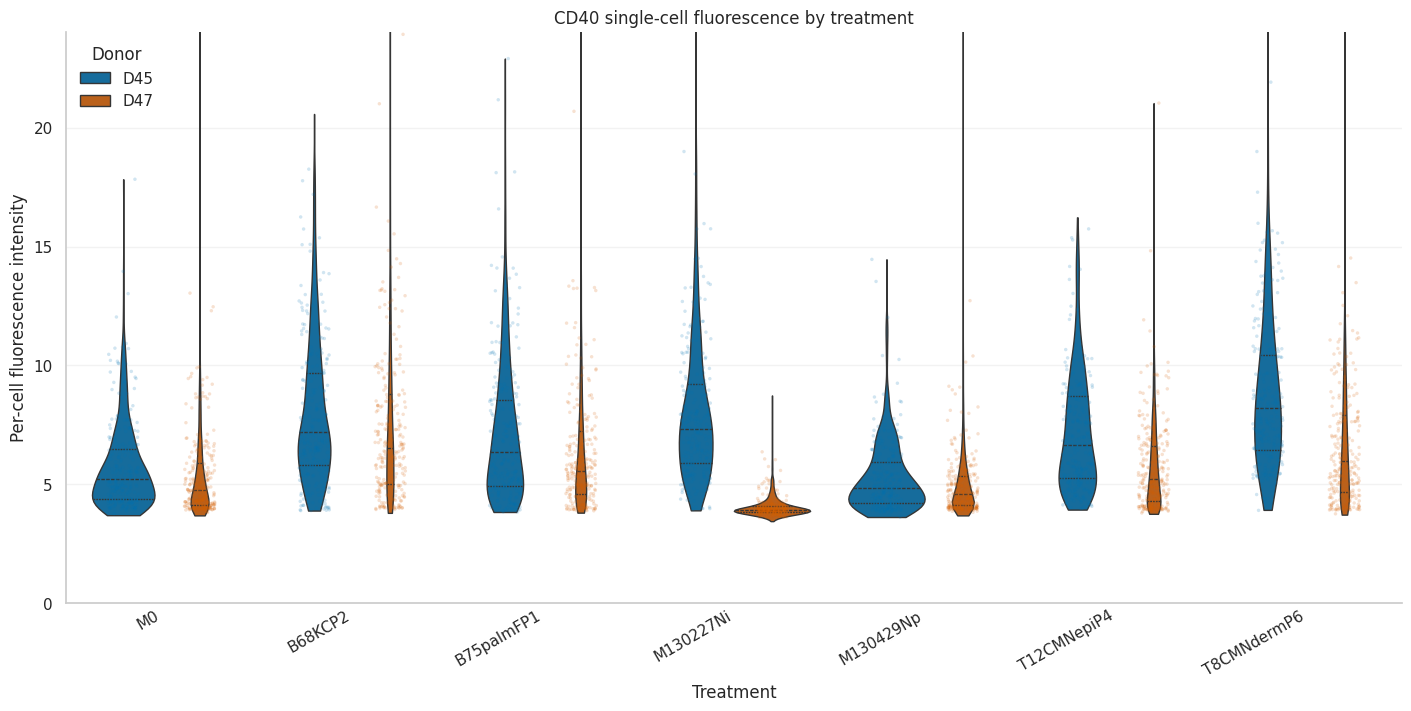

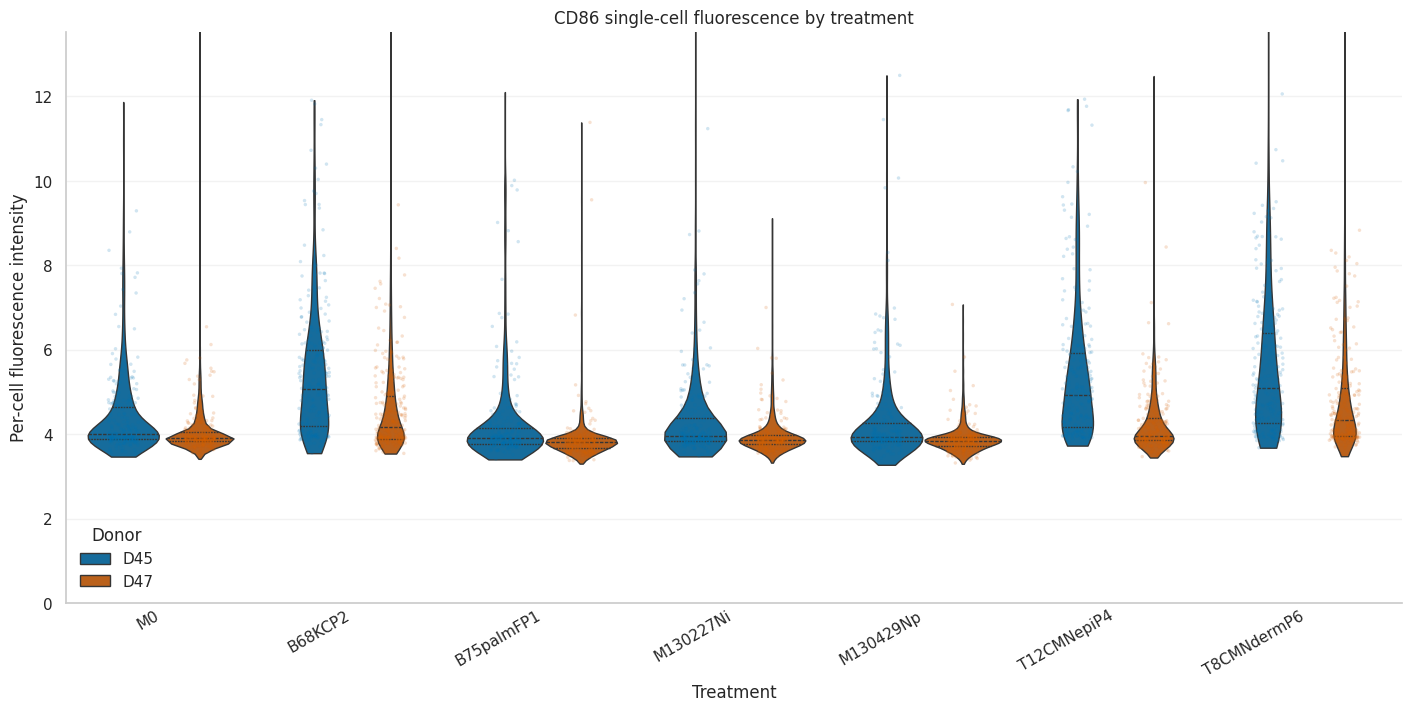

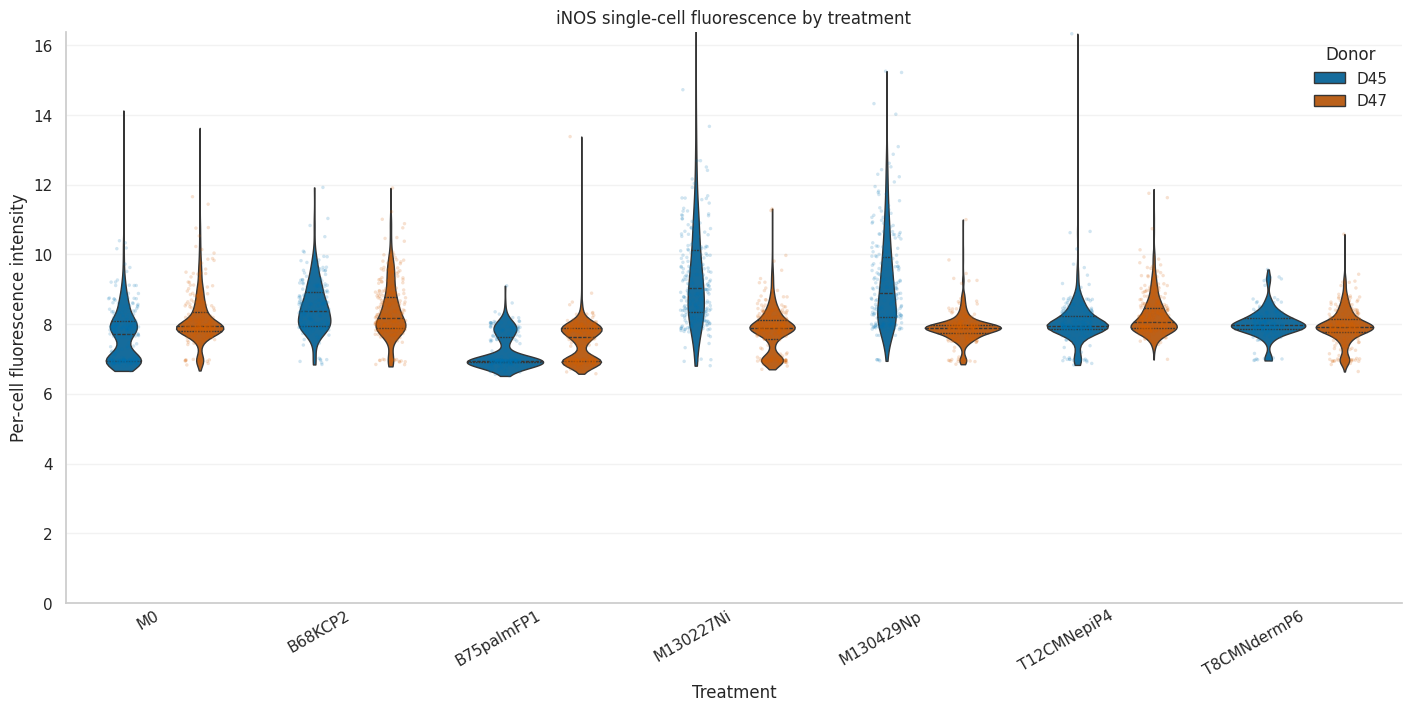

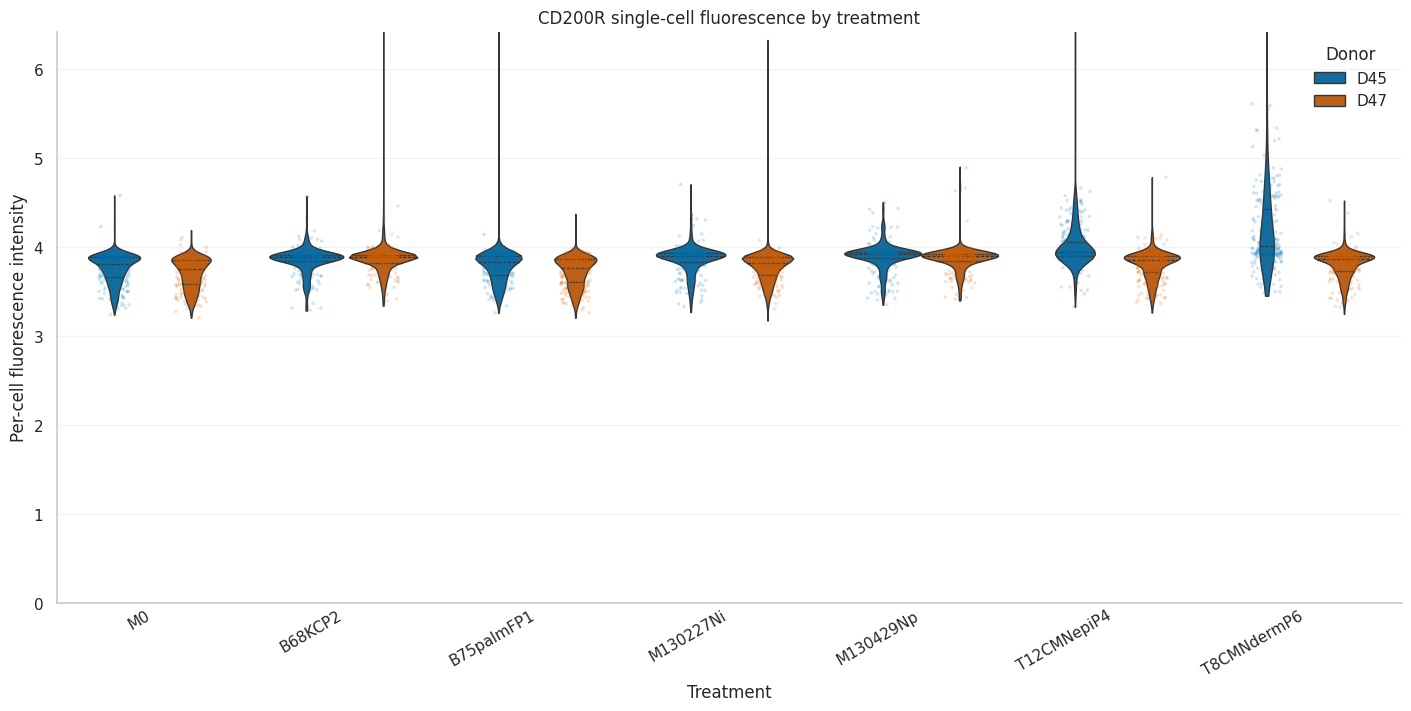

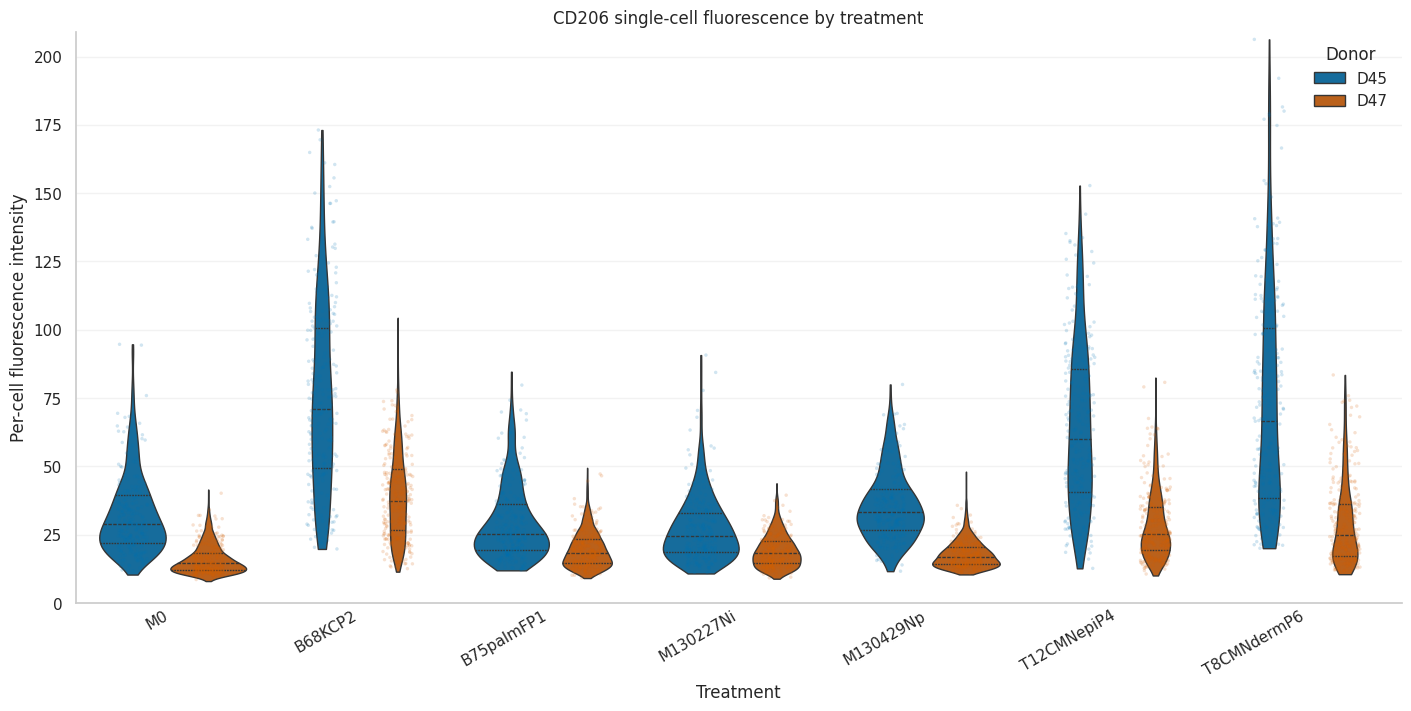

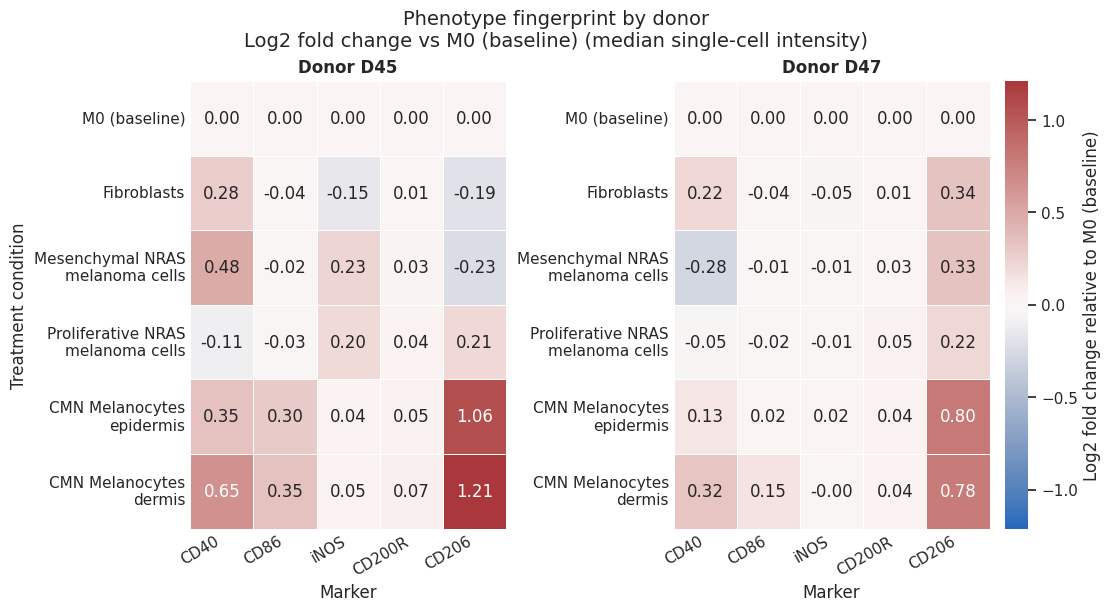

**CD40**

```text
     Condition     Donor  Cells Median Mean   p-value     Sig.
 M0 (baseline) Donor D45    610   5.23 5.71  baseline baseline
 M0 (baseline) Donor D47   1960   4.76 5.35  baseline baseline
      B68 KCP2 Donor D45    718   7.19 8.02  5.86e-60     ****
      B68 KCP2 Donor D47   1298   6.51 7.38  6.5e-113     ****
  B75 palm FP1 Donor D45    816   6.34 7.10  1.56e-22     ****
  B75 palm FP1 Donor D47   2320   5.56 6.26  2.89e-55     ****
    M130227 Ni Donor D45    775   7.30 8.03  1.98e-69     ****
    M130227 Ni Donor D47   1444   3.92 4.04 4.09e-280     ****
    M130429 Np Donor D45    412   4.85 5.31  3.72e-05     ****
    M130429 Np Donor D47   1580   4.59 4.96  6.64e-08     ****
T12 CMN epi P4 Donor D45    672   6.64 7.17   2.6e-33     ****
T12 CMN epi P4 Donor D47   1849   5.22 5.72  1.46e-16     ****
T8 CMN derm P6 Donor D45    339   8.18 8.96  8.72e-64     ****
T8 CMN derm P6 Donor D47   1322   5.96 6.56  1.18e-60     ****
```

**CD86**

```text
     Condition     Donor  Cells Median Mean   p-value     Sig.
 M0 (baseline) Donor D45    564   4.00 4.43  baseline baseline
 M0 (baseline) Donor D47   2268   3.90 4.05  baseline baseline
      B68 KCP2 Donor D45    420   5.07 5.38  5.17e-41     ****
      B68 KCP2 Donor D47   1171   4.18 4.56  2.21e-70     ****
  B75 palm FP1 Donor D45    585   3.90 4.25  5.18e-16     ****
  B75 palm FP1 Donor D47   1437   3.81 3.84  3.25e-96     ****
    M130227 Ni Donor D45    550   3.95 4.35  0.000845      ***
    M130227 Ni Donor D47   1368   3.87 3.97  9.86e-17     ****
    M130429 Np Donor D45    390   3.92 4.29  1.19e-06     ****
    M130429 Np Donor D47   1250   3.85 3.89   1.1e-40     ****
T12 CMN epi P4 Donor D45    663   4.92 5.35  7.37e-52     ****
T12 CMN epi P4 Donor D47   1269   3.96 4.27  3.72e-19     ****
T8 CMN derm P6 Donor D45    323   5.09 5.61  6.15e-41     ****
T8 CMN derm P6 Donor D47    809   4.33 4.78 5.63e-120     ****
```

**iNOS**

```text
     Condition     Donor  Cells Median Mean  p-value     Sig.
 M0 (baseline) Donor D45    479   7.72 7.68 baseline baseline
 M0 (baseline) Donor D47   1613   7.93 8.14 baseline baseline
      B68 KCP2 Donor D45    216   8.37 8.48 2.43e-34     ****
      B68 KCP2 Donor D47    778   8.17 8.38 8.36e-17     ****
  B75 palm FP1 Donor D45    211   6.95 7.20 2.81e-17     ****
  B75 palm FP1 Donor D47    665   7.64 7.49 3.76e-96     ****
    M130227 Ni Donor D45    372   9.04 9.41 1.31e-78     ****
    M130227 Ni Donor D47   1094   7.88 7.85 2.13e-17     ****
    M130429 Np Donor D45    238   8.88 9.25 3.13e-58     ****
    M130429 Np Donor D47    567   7.90 7.89 1.11e-12     ****
T12 CMN epi P4 Donor D45    481   7.96 8.05 6.83e-21     ****
T12 CMN epi P4 Donor D47    772   8.06 8.27 4.42e-11     ****
T8 CMN derm P6 Donor D45    201   7.97 8.02 3.49e-13     ****
T8 CMN derm P6 Donor D47    514   7.92 7.94 0.000321      ***
```

**CD200R**

```text
     Condition     Donor  Cells Median Mean   p-value     Sig.
 M0 (baseline) Donor D45    544   3.81 3.76  baseline baseline
 M0 (baseline) Donor D47   1346   3.75 3.71  baseline baseline
      B68 KCP2 Donor D45    247   3.89 3.85  1.05e-16     ****
      B68 KCP2 Donor D47    975   3.89 3.86 3.53e-116     ****
  B75 palm FP1 Donor D45    563   3.83 3.78     0.031        *
  B75 palm FP1 Donor D47   1337   3.77 3.73    0.0119        *
    M130227 Ni Donor D45    319   3.90 3.86  2.56e-29     ****
    M130227 Ni Donor D47   1314   3.82 3.78  2.43e-25     ****
    M130429 Np Donor D45    362   3.92 3.90  3.76e-54     ****
    M130429 Np Donor D47    807   3.89 3.87 6.64e-125     ****
T12 CMN epi P4 Donor D45    340   3.94 4.01  1.41e-81     ****
T12 CMN epi P4 Donor D47    869   3.85 3.80  1.15e-41     ****
T8 CMN derm P6 Donor D45    320   4.01 4.22  1.02e-81     ****
T8 CMN derm P6 Donor D47    617   3.86 3.81  1.96e-40     ****
```

**CD206**

```text
     Condition     Donor  Cells Median  Mean   p-value     Sig.
 M0 (baseline) Donor D45    643  28.83 32.53  baseline baseline
 M0 (baseline) Donor D47   1843  14.47 16.05  baseline baseline
      B68 KCP2 Donor D45    311  70.81 75.58  4.61e-83     ****
      B68 KCP2 Donor D47   1047  37.43 39.04         0     ****
  B75 palm FP1 Donor D45    421  25.24 29.17   1.1e-05     ****
  B75 palm FP1 Donor D47   1876  18.30 19.56  5.55e-77     ****
    M130227 Ni Donor D45    318  24.63 27.21  2.59e-09     ****
    M130227 Ni Donor D47   1103  18.21 19.17  5.94e-53     ****
    M130429 Np Donor D45    382  33.34 35.46   8.1e-07     ****
    M130429 Np Donor D47   1461  16.87 17.77  1.54e-38     ****
T12 CMN epi P4 Donor D45    330  60.09 64.32  6.68e-67     ****
T12 CMN epi P4 Donor D47    780  25.17 28.31 1.17e-184     ****
T8 CMN derm P6 Donor D45    289  66.72 72.38  2.55e-62     ****
T8 CMN derm P6 Donor D47    599  24.85 28.95 6.14e-117     ****
```

In [6]:
batch_stats = ma.plot_violins_with_stats(
    batch_results,
    plot_log_scale=batch_plot_log_scale,
    upper_display_percentile=batch_plot_upper_percentile,
)
ma.plot_summary_heatmap(
    batch_results, 
    stat_results=batch_stats,
    show_significance_stars=False,
    exclude_treatment="B68KCP2",
    condition_label_style="descriptive",
)
ma.display_stat_summary_tables(
    batch_stats,
    baseline_condition=batch_results.baseline_condition,
)
